In [10]:
import torch
from tqdm import tqdm
from sklearn.metrics import f1_score, recall_score, precision_score
import torch.nn.functional as F
import numpy as np
from IPython.display import clear_output
from torch.utils.data import Dataset
from torchvision.transforms.v2 import Compose, PILToTensor, ToDtype, Normalize, Grayscale, ToImage, ToTensor, RandomHorizontalFlip, Resize
from torch.utils.data import DataLoader
import os
import PIL
from PIL import Image
from torchvision.transforms import ToPILImage
import pandas as pd
import torchvision.transforms as tt
import torch.nn as nn


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

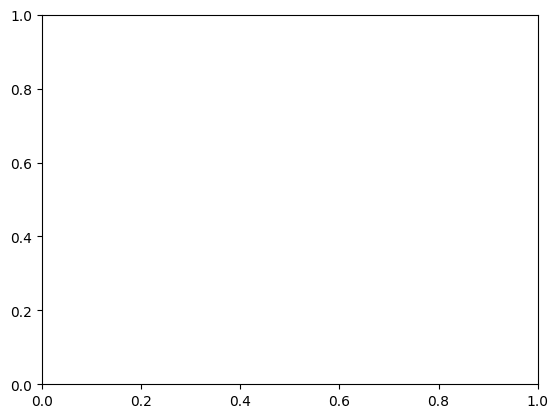

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

plt.show()

In [16]:

OPS = {
  'none' : lambda C_in, C_out, stride, affine: Zero(stride),
  'avg_pool_3x3' : lambda C_in, C_out, stride, affine: nn.AvgPool2d(3, stride=stride, padding=1, count_include_pad=False) if C_in == C_out else nn.Sequential(
    nn.AvgPool2d(3, stride=stride, padding=1, count_include_pad=False),
    nn.Conv2d(C_in, C_out, 1, stride=1, padding=0, bias=False),
    nn.BatchNorm2d(C_out, eps=1e-3, affine=affine)
    ),
  'max_pool_3x3' : lambda C_in, C_out, stride, affine: nn.MaxPool2d(3, stride=stride, padding=1) if C_in == C_out else nn.Sequential(
    nn.MaxPool2d(3, stride=stride, padding=1),
    nn.Conv2d(C_in, C_out, 1, stride=1, padding=0, bias=False),
    nn.BatchNorm2d(C_out, eps=1e-3, affine=affine)
    ),
  'skip_connect' : lambda C_in, C_out, stride, affine: Identity() if stride == 1 else ReLUConvBN(C_in, C_out, 1, stride, 0, affine=affine),
  'sep_conv_3x3' : lambda C_in, C_out, stride, affine: SepConv(C_in, C_out, 3, stride, 1, affine=affine),
  'sep_conv_5x5' : lambda C_in, C_out, stride, affine: SepConv(C_in, C_out, 5, stride, 2, affine=affine),
  'sep_conv_7x7' : lambda C_in, C_out, stride, affine: SepConv(C_in, C_out, 7, stride, 3, affine=affine),
  'dil_conv_3x3' : lambda C_in, C_out, stride, affine: DilConv(C_in, C_out, 3, stride, 2, 2, affine=affine),
  'dil_conv_5x5' : lambda C_in, C_out, stride, affine: DilConv(C_in, C_out, 5, stride, 4, 2, affine=affine),
  'conv_7x1_1x7' : lambda C_in, C_out, stride, affine: nn.Sequential(
    nn.ReLU(inplace=False),
    nn.Conv2d(C_in, C_in, (1,7), stride=(1, stride), padding=(0, 3), bias=False),
    nn.Conv2d(C_in, C_out, (7,1), stride=(stride, 1), padding=(3, 0), bias=False),
    nn.BatchNorm2d(C_out, eps=1e-3, affine=affine)
    ),
}

class ReLUConvBN(nn.Module):

  def __init__(self, C_in, C_out, kernel_size, stride, padding, affine=True):
    super(ReLUConvBN, self).__init__()
    self.op = nn.Sequential(
      nn.ReLU(inplace=False),
      nn.Conv2d(C_in, C_out, kernel_size, stride=stride, padding=padding, bias=False),
      nn.BatchNorm2d(C_out, eps=1e-3, affine=affine)
    )

  def forward(self, x):
    return self.op(x)

class DilConv(nn.Module):
    
  def __init__(self, C_in, C_out, kernel_size, stride, padding, dilation, affine=True):
    super(DilConv, self).__init__()
    self.op = nn.Sequential(
      nn.ReLU(inplace=False),
      nn.Conv2d(C_in, C_in, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, groups=C_in, bias=False),
      nn.Conv2d(C_in, C_out, kernel_size=1, padding=0, bias=False),
      nn.BatchNorm2d(C_out, eps=1e-3, affine=affine),
      )

  def forward(self, x):
    return self.op(x)


class SepConv(nn.Module):
    
  def __init__(self, C_in, C_out, kernel_size, stride, padding, affine=True):
    super(SepConv, self).__init__()
    self.op = nn.Sequential(
      nn.ReLU(inplace=False),
      nn.Conv2d(C_in, C_in, kernel_size=kernel_size, stride=stride, padding=padding, groups=C_in, bias=False),
      nn.Conv2d(C_in, C_out, kernel_size=1, padding=0, bias=False),
      nn.BatchNorm2d(C_out, eps=1e-3, affine=affine),
      nn.ReLU(inplace=False),
      nn.Conv2d(C_out, C_out, kernel_size=kernel_size, stride=1, padding=padding, groups=C_out, bias=False),
      nn.Conv2d(C_out, C_out, kernel_size=1, padding=0, bias=False),
      nn.BatchNorm2d(C_out, eps=1e-3, affine=affine),
      )

  def forward(self, x):
    return self.op(x)


class Identity(nn.Module):

  def __init__(self):
    super(Identity, self).__init__()

  def forward(self, x):
    return x


class Zero(nn.Module):

  def __init__(self, stride):
    super(Zero, self).__init__()
    self.stride = stride

  def forward(self, x):
    if self.stride == 1:
      return x.mul(0.)
    return x[:,:,::self.stride,::self.stride].mul(0.)


class FactorizedReduce(nn.Module):

  def __init__(self, C_in, C_out, affine=True):
    super(FactorizedReduce, self).__init__()
    assert C_out % 2 == 0
    self.relu = nn.ReLU(inplace=False)
    self.conv_1 = nn.Conv2d(C_in, C_out // 2, 1, stride=2, padding=0, bias=False)
    self.conv_2 = nn.Conv2d(C_in, C_out // 2, 1, stride=2, padding=0, bias=False) 
    self.bn = nn.BatchNorm2d(C_out, eps=1e-3, affine=affine)
    self.pad = nn.ConstantPad2d((0, 1, 0, 1), 0)

  def forward(self, x):
    x = self.relu(x)
    y = self.pad(x)
    out = torch.cat([self.conv_1(x), self.conv_2(y[:,:,1:,1:])], dim=1)
    out = self.bn(out)
    return out

In [17]:
import torch
import torch.nn as nn
from torch.autograd import Variable
# from utils import drop_path


class Cell(nn.Module):

  def __init__(self, genotype, C_prev_prev, C_prev, C, reduction, reduction_prev):
    super(Cell, self).__init__()
    print(C_prev_prev, C_prev, C)
    self.reduction = reduction

    if reduction_prev is None:
      self.preprocess0 = Identity()
    elif reduction_prev is True:
      self.preprocess0 = FactorizedReduce(C_prev_prev, C)
    else:
      self.preprocess0 = ReLUConvBN(C_prev_prev, C, 1, 1, 0)
    self.preprocess1 = ReLUConvBN(C_prev, C, 1, 1, 0)
    
    if reduction:
      op_names, indices = zip(*genotype.reduce)
      concat = genotype.reduce_concat
    else:
      op_names, indices = zip(*genotype.normal)
      concat = genotype.normal_concat

    assert len(op_names) == len(indices)
    self._steps = len(op_names) // 2
    self._concat = concat
    self.multiplier = len(concat)

    self._ops = nn.ModuleList()
    for name, index in zip(op_names, indices):
      stride = 2 if reduction and index < 2 else 1
      if reduction_prev is None and index == 0:
        op = OPS[name](C_prev_prev, C, stride, True)
      else:
        op = OPS[name](C, C, stride, True)
      self._ops += [op]
    self._indices = indices

  def forward(self, s0, s1, drop_prob):
    s0 = self.preprocess0(s0)
    s1 = self.preprocess1(s1)

    states = [s0, s1]
    for i in range(self._steps):
      h1 = states[self._indices[2*i]]
      h2 = states[self._indices[2*i+1]]
      op1 = self._ops[2*i]
      op2 = self._ops[2*i+1]
      h1 = op1(h1)
      h2 = op2(h2)
      # if self.training and drop_prob > 0.:
      #   if not isinstance(op1, Identity):
      #     h1 = drop_path(h1, drop_prob)
      #   if not isinstance(op2, Identity):
      #     h2 = drop_path(h2, drop_prob)
      s = h1 + h2
      states += [s]
    return torch.cat([states[i] for i in self._concat], dim=1)


class AuxiliaryHeadImageNet(nn.Module):

  def __init__(self, C, num_classes):
    """assuming input size 14x14"""
    super(AuxiliaryHeadImageNet, self).__init__()
    self.features = nn.Sequential(
      nn.ReLU(inplace=True),
      nn.AvgPool2d(5, stride=2, padding=0, count_include_pad=False),
      nn.Conv2d(C, 128, 1, bias=False),
      nn.BatchNorm2d(128),
      nn.ReLU(inplace=True),
      nn.Conv2d(128, 768, 2, bias=False),
      nn.BatchNorm2d(768),
      nn.ReLU(inplace=True)
    )
    self.classifier = nn.Linear(768, num_classes)

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x.view(x.size(0),-1))
    return x


class NetworkImageNet(nn.Module):

  def __init__(self, C, num_classes, layers, auxiliary, genotype):
    super(NetworkImageNet, self).__init__()
    self._layers = layers
    self._auxiliary = auxiliary

    self.conv0 = nn.Conv2d(3, 96, kernel_size=3, stride=2, padding=0, bias=False)
    self.conv0_bn = nn.BatchNorm2d(96, eps=1e-3)
    self.stem1 = Cell(genotype, 96, 96, C // 4, True, None)
    self.stem2 = Cell(genotype, 96, C * self.stem1.multiplier // 4, C // 2, True, True)

    C_prev_prev, C_prev, C_curr = C * self.stem1.multiplier // 4, C * self.stem2.multiplier // 2, C

    self.cells = nn.ModuleList()
    reduction_prev = True
    for i in range(layers):
      if i in [layers // 3, 2 * layers // 3]:
        C_curr *= 2
        reduction = True
      else:
        reduction = False
      cell = Cell(genotype, C_prev_prev, C_prev, C_curr, reduction, reduction_prev)
      reduction_prev = reduction
      self.cells += [cell]
      C_prev_prev, C_prev = C_prev, cell.multiplier * C_curr
      if i == 2 * layers // 3:
        C_to_auxiliary = C_prev

    if auxiliary:
      self.auxiliary_head = AuxiliaryHeadImageNet(C_to_auxiliary, num_classes)
    self.relu = nn.ReLU(inplace=False)
    self.global_pooling = nn.AdaptiveAvgPool2d(1)
    self.classifier = nn.Linear(C_prev, num_classes)

  def forward(self, input):
    logits_aux = None
    s0 = self.conv0(input)
    s0 = self.conv0_bn(s0)
    s1 = self.stem1(s0, s0, None)
    s0, s1 = s1, self.stem2(s0, s1, None)
    for i, cell in enumerate(self.cells):
      s0, s1 = s1, cell(s0, s1, None)
    s1 = self.relu(s1)
    out = self.global_pooling(s1)
    logits = self.classifier(out.view(out.size(0), -1))
    logits_aux = torch.topk(logits, 1, dim=1).indices
    return logits

In [18]:
from collections import namedtuple

Genotype = namedtuple('Genotype', 'normal normal_concat reduce reduce_concat')

PNASNet = Genotype(
  normal = [
    ('sep_conv_5x5', 0),
    ('max_pool_3x3', 0),
    ('sep_conv_7x7', 1),
    ('max_pool_3x3', 1),
    ('sep_conv_5x5', 1),
    ('sep_conv_3x3', 1),
    ('sep_conv_3x3', 4),
    ('max_pool_3x3', 1),
    ('sep_conv_3x3', 0),
    ('skip_connect', 1),
  ],
  normal_concat = [2, 3, 4, 5, 6],
  reduce = [
    ('sep_conv_5x5', 0),
    ('max_pool_3x3', 0),
    ('sep_conv_7x7', 1),
    ('max_pool_3x3', 1),
    ('sep_conv_5x5', 1),
    ('sep_conv_3x3', 1),
    ('sep_conv_3x3', 4),
    ('max_pool_3x3', 1),
    ('sep_conv_3x3', 0),
    ('skip_connect', 1),
  ],
  reduce_concat = [2, 3, 4, 5, 6],
)

In [19]:
import argparse
import os
import tensorflow as tf
import torch
import torchvision.datasets as datasets
from torch.autograd import Variable
import torch.nn as nn
from torchsummary import summary

model = NetworkImageNet(108, 10,
                          12, False, PNASNet)
#model = NetworkImageNet(256, 10,
#                          16, False, PNASNet)
#model = NetworkImageNet(224, 10,
                         # 12, False, PNASNet)

summary(model, (3, 256, 256), device="cuda")

96 96 27
96 135 54
135 270 108
270 540 108
540 540 108
540 540 108
540 540 216
540 1080 216
1080 1080 216
1080 1080 216
1080 1080 432
1080 2160 432
2160 2160 432
2160 2160 432
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 96, 127, 127]           2,592
       BatchNorm2d-2         [-1, 96, 127, 127]             192
          Identity-3         [-1, 96, 127, 127]               0
              ReLU-4         [-1, 96, 127, 127]               0
            Conv2d-5         [-1, 27, 127, 127]           2,592
       BatchNorm2d-6         [-1, 27, 127, 127]              54
        ReLUConvBN-7         [-1, 27, 127, 127]               0
              ReLU-8         [-1, 96, 127, 127]               0
            Conv2d-9           [-1, 96, 64, 64]           2,400
           Conv2d-10           [-1, 27, 64, 64]           2,592
      BatchNorm2d-11           [-1, 27, 64, 64]        